## What is XGBoost and when to use it

XGBoost builds many small decision trees sequentially. Each new tree focuses on correcting the mistakes of all previous ones. This process is called Gradient Boosting.
Tree 1 → makes predictions → has errors
Tree 2 → learns from Tree 1's errors → smaller errors
Tree 3 → learns from Tree 2's errors → even smaller
...
Final prediction = sum of all trees weighted by learning rate


#### Use XGBoost when:

Your data is tabular (CSV, Excel, SQL)
You need classification or regression
You need feature importance
Your data has missing values
You need fast training with high accuracy

#### Do NOT use XGBoost for:

Images → use CNNs
Raw text → use Transformers
Complex sequences → use LSTMs

first model (simplest possible):

In [1]:
# the minimum code to get XGBoost running
# using breast cancer dataset — 569 samples, 30 features, binary classification

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# load data
data = load_breast_cancer()
X, y = data.data, data.target
# y = 0 (malignant) or 1 (benign)

# split into train and test — always stratify for classification
# stratify=y keeps the same class ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # reproducibility
    stratify=y,         # preserve class ratio
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

# train — XGBClassifier works exactly like sklearn estimators
model = xgb.XGBClassifier(
    n_estimators=100,   # number of trees
    random_state=42,
)
model.fit(X_train, y_train)

# predict and evaluate
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")    # typically ~0.97

Train : (455, 30)
Test  : (114, 30)

Accuracy: 0.9561


### Full classification with all metrics
#### When to use which metric:

Accuracy — only for balanced datasets

Precision — when false positives are costly (spam filter)

Recall — when false negatives are costly (fraud, cancer detection)

F1 — balance between precision and recall, good for imbalanced data

ROC AUC — overall model ranking quality, threshold-independent.


CLASSIFICATION METRICS
Accuracy  : 0.9561
Precision : 0.9467
Recall    : 0.9861
F1 Score  : 0.9660
ROC AUC   : 0.9937

Full Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



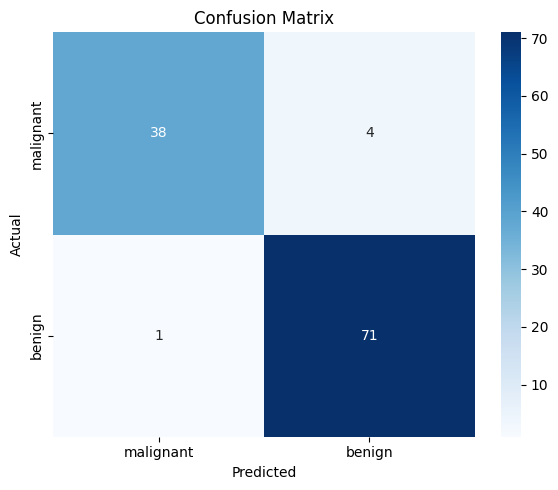

In [2]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
)

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,          # use 80% of rows per tree
    colsample_bytree=0.8,   # use 80% of columns per tree
    random_state=42,
)
model.fit(X_train, y_train)

# predict class labels AND probabilities
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1

# all metrics at once
print("=" * 45)
print("CLASSIFICATION METRICS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")

print("\nFull Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# confusion matrix — rows=actual, columns=predicted
# diagonal = correct predictions
# off-diagonal = errors
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Regression




REGRESSION METRICS
MAE  : 0.3120   (avg error in $100k)
RMSE : 0.4693
R²   : 0.8319    (% of variance explained)


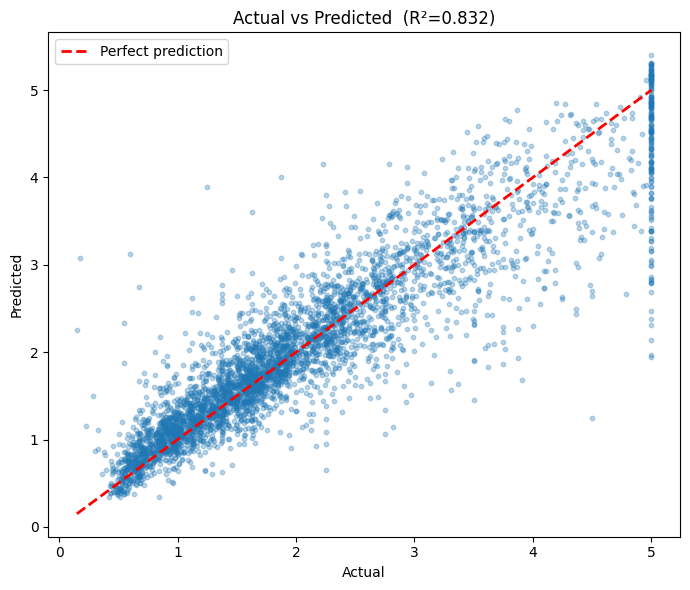

In [3]:
# XGBRegressor for predicting continuous values
# use case: price prediction, demand forecasting, revenue estimation

import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = fetch_california_housing()
X, y = data.data, data.target
# y = median house value in $100k units

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBRegressor instead of XGBClassifier — same API
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 regularization — promotes sparsity
    reg_lambda=1.0,     # L2 regularization — smooths weights
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# regression metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("REGRESSION METRICS")
print("=" * 40)
# MAE  = average absolute error (same unit as y — easy to interpret)
# RMSE = penalizes large errors more than MAE
# R²   = 1.0 perfect, 0.0 = predicts the mean, <0 = worse than mean
print(f"MAE  : {mae:.4f}   (avg error in $100k)")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}    (% of variance explained)")

# actual vs predicted plot — points should align on the diagonal
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted  (R²={r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

### DMatrix (XGBoost native format)

DMatrix is XGBoost's internal data structure. It is faster and more memory-efficient than numpy arrays. Use it when working with the native xgb.train() API or large datasets.

In [4]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# wrap data in DMatrix — stores data + labels + feature names together
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=feature_names)

print(f"DMatrix: {dtrain.num_row()} rows × {dtrain.num_col()} cols")

# native xgb.train() API — more control than XGBClassifier
# requires params dict instead of constructor arguments
params = {
    "objective":   "binary:logistic",   # binary classification
    "eval_metric": "logloss",           # metric to monitor
    "max_depth":   4,
    "eta":         0.1,                 # eta = learning_rate in native API
    "subsample":   0.8,
    "seed":        42,
}

# watchlist = list of (DMatrix, name) tuples to monitor during training
watchlist = [(dtrain, "train"), (dtest, "eval")]

model = xgb.train(
    params         = params,
    dtrain         = dtrain,
    num_boost_round = 200,          # number of trees
    evals          = watchlist,
    verbose_eval   = 50,            # print metrics every 50 rounds
)

# native API returns raw scores → apply sigmoid to get probabilities
import numpy as np
y_pred_prob = model.predict(dtest)                   # already probabilities for binary:logistic
y_pred      = (y_pred_prob > 0.5).astype(int)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

DMatrix: 455 rows × 30 cols
[0]	train-logloss:0.57898	eval-logloss:0.58388
[50]	train-logloss:0.02871	eval-logloss:0.10482
[100]	train-logloss:0.01271	eval-logloss:0.10061
[150]	train-logloss:0.00895	eval-logloss:0.10179
[199]	train-logloss:0.00768	eval-logloss:0.09840

Accuracy: 0.9649


# All important parameters explained

In [5]:
import xgboost as xgb

# this cell is a reference — run it to see all params
# every parameter is explained so you understand what to tune

model = xgb.XGBClassifier(

    # ── TREE COUNT ────────────────────────────────────────────
    n_estimators = 300,
    # How many trees to build.
    # More = better fit but risk of overfitting and slower training.
    # Always use early_stopping_rounds to find the optimal value.

    # ── TREE STRUCTURE ────────────────────────────────────────
    max_depth = 6,
    # Max depth of each tree. Default = 6.
    # Deeper = more complex model = more overfitting risk.
    # Typical range: 3–10. Start with 4–6.

    min_child_weight = 1,
    # Min sum of sample weights in a leaf.
    # Higher = more conservative = less overfitting.
    # Increase this if you have noisy data or small classes.

    gamma = 0,
    # Min loss reduction required to make a split.
    # Higher = fewer splits = simpler trees.
    # Range: 0–5. Start at 0, increase if overfitting.

    # ── LEARNING ──────────────────────────────────────────────
    learning_rate = 0.1,
    # Shrinks the contribution of each tree. Also called eta.
    # Lower = slower learning = needs more trees = better generalization.
    # Rule: lower learning_rate → higher n_estimators.
    # Typical range: 0.01–0.3.

    # ── SAMPLING (randomness = less overfitting) ──────────────
    subsample = 0.8,
    # Fraction of training rows used per tree.
    # Adds randomness, reduces overfitting, like Random Forest.
    # Range: 0.5–1.0.

    colsample_bytree = 0.8,
    # Fraction of features used per tree.
    # Range: 0.5–1.0.

    colsample_bylevel = 1.0,
    # Fraction of features used per depth level.

    colsample_bynode = 1.0,
    # Fraction of features used per split.

    # ── REGULARIZATION (penalizes complexity) ─────────────────
    reg_alpha = 0.0,
    # L1 regularization (like Lasso).
    # Makes weights sparse — good when many features are irrelevant.
    # Range: 0–1.

    reg_lambda = 1.0,
    # L2 regularization (like Ridge). Default = 1.
    # Smooths weights — main regularization in XGBoost.
    # Range: 0–10.

    # ── IMBALANCED DATA ───────────────────────────────────────
    scale_pos_weight = 1,
    # Set to neg/pos count ratio for imbalanced datasets.
    # Example: 900 normal / 100 fraud → scale_pos_weight = 9
    # Tells XGBoost to penalize missing the minority class more.

    # ── OBJECTIVE (what to optimize) ──────────────────────────
    objective = "binary:logistic",
    # binary:logistic    → binary classification (returns probabilities)
    # multi:softmax      → multiclass (returns class labels)
    # multi:softprob     → multiclass (returns probabilities)
    # reg:squarederror   → regression (MSE loss)
    # reg:absoluteerror  → regression (MAE loss)

    # ── EVALUATION METRIC ─────────────────────────────────────
    eval_metric = "logloss",
    # logloss    → binary classification
    # mlogloss   → multiclass
    # error      → classification error rate
    # auc        → ROC AUC
    # rmse / mae → regression

    # ── HARDWARE ──────────────────────────────────────────────
    device  = "cpu",    # "cpu" or "cuda" for GPU
    n_jobs  = -1,       # use all CPU cores
    random_state = 42,
)

print("Parameters set. Reference cell — do not run fit() here.")

Parameters set. Reference cell — do not run fit() here.


## Early stopping
Problem: how do you know the right number of trees?

Too few → underfitting

Too many → overfitting

Solution: early stopping — stop training when the validation metric stops improving.

[0]	validation_0-logloss:0.64909
[100]	validation_0-logloss:0.08203
[200]	validation_0-logloss:0.08016
[219]	validation_0-logloss:0.08068

Best iteration : 169
Best val score : 0.0787
Test accuracy  : 0.9535


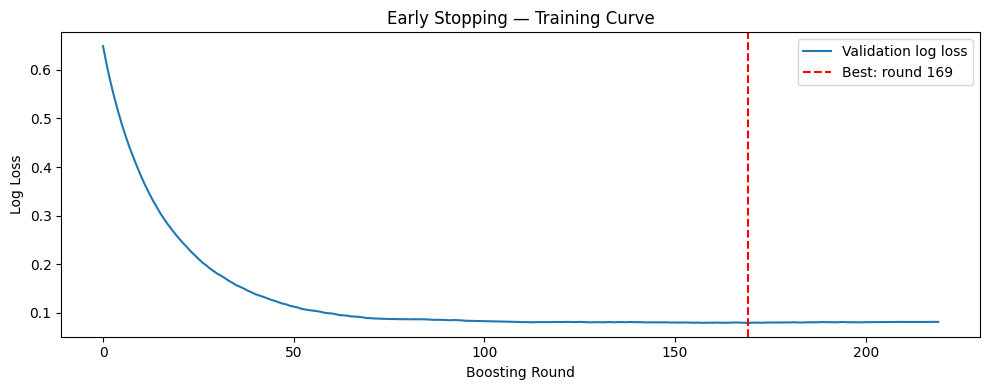

In [6]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

# need a validation set — separate from test set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = xgb.XGBClassifier(
    n_estimators          = 1000,     # set high — early stopping will find the sweet spot
    learning_rate         = 0.05,
    max_depth             = 4,
    early_stopping_rounds = 50,       # stop if no improvement for 50 consecutive rounds
    eval_metric           = "logloss",
    random_state          = 42,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],      # monitor validation loss
    verbose  = 100,                   # print every 100 rounds
)

# best_iteration = round with lowest validation loss
# best_score     = the lowest validation loss achieved
print(f"\nBest iteration : {model.best_iteration}")
print(f"Best val score : {model.best_score:.4f}")
print(f"Test accuracy  : {accuracy_score(y_test, model.predict(X_test)):.4f}")

# plot the training curve — shows when overfitting starts
results     = model.evals_result()
val_loss    = results["validation_0"]["logloss"]

plt.figure(figsize=(10, 4))
plt.plot(val_loss, label="Validation log loss")
plt.axvline(x=model.best_iteration, color="red", linestyle="--",
            label=f"Best: round {model.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("Early Stopping — Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

### Cross validation

Why cross validation? A single train/test split can be misleading — maybe you got lucky with the split. 

Cross validation trains K models on K different splits and averages the results for a more reliable estimate.

In [7]:
import xgboost as xgb
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold

data = load_breast_cancer()
X, y = data.data, data.target

model = xgb.XGBClassifier(
    n_estimators  = 200,
    max_depth     = 4,
    learning_rate = 0.1,
    random_state  = 42,
)

# StratifiedKFold preserves class ratio in each fold
# crucial for imbalanced datasets — always use it for classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model, X, y,
    cv      = cv,
    scoring = "roc_auc",  # metric to evaluate
    n_jobs  = -1,         # parallel
)

print("=" * 40)
print("5-FOLD CROSS VALIDATION")
print("=" * 40)
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")

print(f"\nMean  AUC : {scores.mean():.4f}")
print(f"Std   AUC : {scores.std():.4f}")
# 95% confidence interval — real-world performance will be in this range
print(f"95% CI    : [{scores.mean()-2*scores.std():.4f}, {scores.mean()+2*scores.std():.4f}]")

# ── Native xgb.cv() — includes early stopping per fold ────────
dtrain = xgb.DMatrix(X, label=y)

params = {"objective": "binary:logistic", "eval_metric": "auc",
          "max_depth": 4, "eta": 0.1, "seed": 42}

cv_results = xgb.cv(
    params               = params,
    dtrain               = dtrain,
    num_boost_round      = 500,
    nfold                = 5,
    stratified           = True,        # stratified folds
    early_stopping_rounds = 30,
    verbose_eval         = 50,
    seed                 = 42,
)

best_round = cv_results["test-auc-mean"].idxmax()
best_auc   = cv_results["test-auc-mean"].max()
best_std   = cv_results.loc[best_round, "test-auc-std"]

print(f"\nBest round : {best_round}")
print(f"Best AUC   : {best_auc:.4f} ± {best_std:.4f}")

5-FOLD CROSS VALIDATION
  Fold 1: 0.9990
  Fold 2: 0.9918
  Fold 3: 0.9874
  Fold 4: 0.9980
  Fold 5: 0.9930

Mean  AUC : 0.9938
Std   AUC : 0.0042
95% CI    : [0.9854, 1.0023]
[0]	train-auc:0.99109+0.00257	test-auc:0.95320+0.01187
[50]	train-auc:1.00000+0.00000	test-auc:0.99021+0.00743
[100]	train-auc:1.00000+0.00000	test-auc:0.99325+0.00348
[150]	train-auc:1.00000+0.00000	test-auc:0.99411+0.00358
[176]	train-auc:1.00000+0.00000	test-auc:0.99411+0.00392

Best round : 146
Best AUC   : 0.9942 ± 0.0035


## Feature importance

### 3 types of importance in XGBoost:

weight — how many times a feature is used for splitting

gain — average improvement in loss per split (most meaningful)

cover — average number of samples affected per split

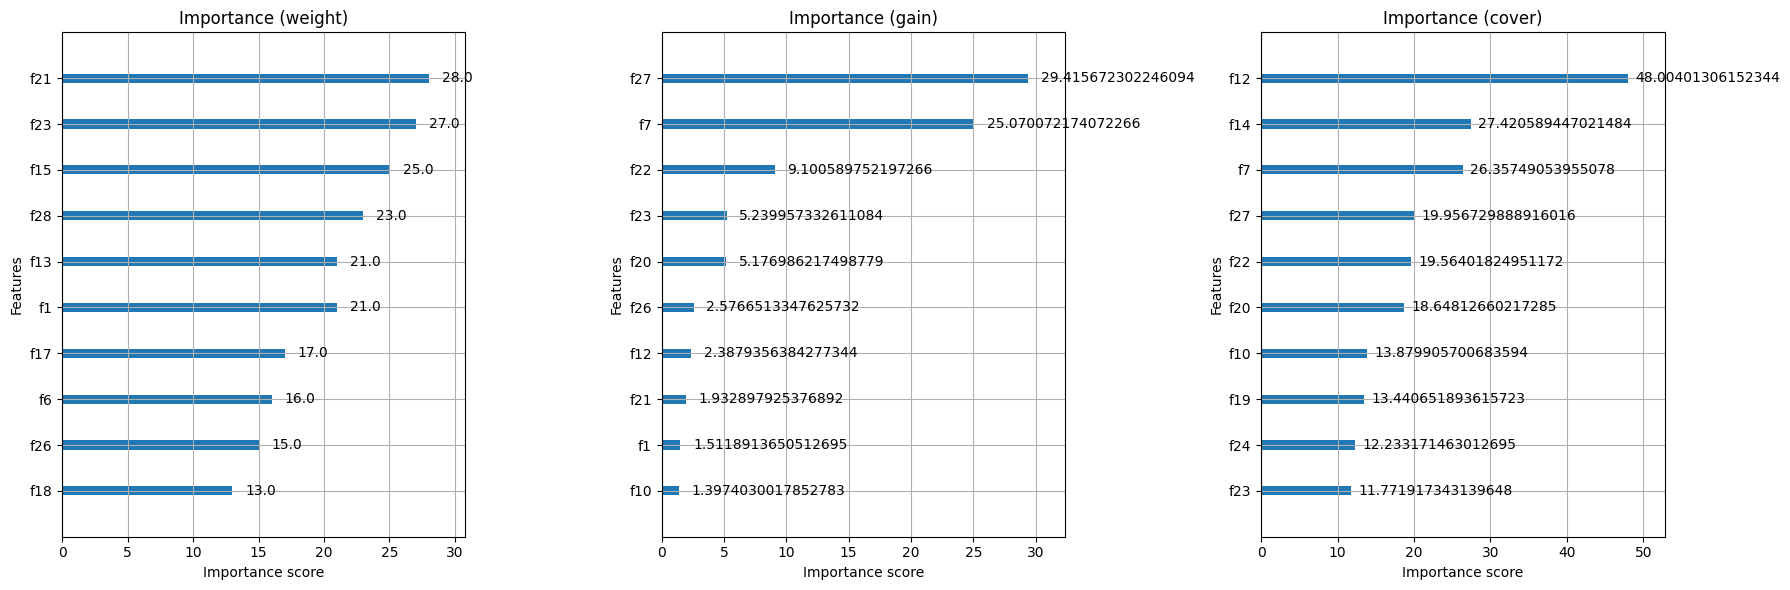

Top 10 features by gain (most predictive):
feature      gain
    f27 29.415672
     f7 25.070072
    f22  9.100590
    f23  5.239957
    f20  5.176986
    f26  2.576651
    f12  2.387936
    f21  1.932898
     f1  1.511891
    f10  1.397403


In [8]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# ── Method 1 — built-in plot ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp_type in zip(axes, ["weight", "gain", "cover"]):
    xgb.plot_importance(model, importance_type=imp_type,
                        ax=ax, max_num_features=10,
                        title=f"Importance ({imp_type})")
plt.tight_layout()
plt.show()

# ── Method 2 — as a pandas DataFrame ─────────────────────────
importances = model.get_booster().get_score(importance_type="gain")

df_imp = (
    pd.DataFrame.from_dict(importances, orient="index", columns=["gain"])
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("gain", ascending=False)
)

print("Top 10 features by gain (most predictive):")
print(df_imp.head(10).to_string(index=False))

# gain is the best metric for understanding which features
# actually contribute to better predictions
# weight can be misleading — a feature used many times for small gains
# is less useful than one used once for a big gain

## Handling missing values
XGBoost handles NaN natively — this is a major advantage. The model learns the best direction to send missing values at each split. No imputation required.

In [9]:
import xgboost as xgb
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

# introduce 15% missing values artificially to test
X_missing = X.copy().astype(float)
np.random.seed(42)
mask = np.random.rand(*X_missing.shape) < 0.15
X_missing[mask] = np.nan

print(f"Missing values: {np.isnan(X_missing).sum():,} ({np.isnan(X_missing).mean():.1%})")

X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y, test_size=0.2, random_state=42
)

# no preprocessing needed — XGBoost accepts NaN directly
# it learns "when feature X is missing, go left or right?"
model = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)    # NaN values are handled internally

y_pred = model.predict(X_test)
print(f"Accuracy with 15% missing : {accuracy_score(y_test, y_pred):.4f}")

# compare against full data to show robustness
X_tr_full, X_te_full, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)
model_full = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model_full.fit(X_tr_full, y_train)
print(f"Accuracy with no missing  : {accuracy_score(y_test, model_full.predict(X_te_full)):.4f}")

# accuracy drop is minimal — XGBoost is very robust to missing values
# this is why it's preferred over sklearn models for real-world dirty data

Missing values: 2,588 (15.2%)
Accuracy with 15% missing : 0.9561
Accuracy with no missing  : 0.9561


## Handling imbalanced datasets
Very common in finance: 99% normal transactions, 1% fraud. A model that always predicts "normal" gets 99% accuracy but is completely useless.

In [10]:
import xgboost as xgb
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# simulate fraud detection: 1% fraud
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    weights=[0.99, 0.01],    # 99% normal, 1% fraud
    random_state=42,
)

print(f"Normal : {(y==0).sum():,} ({(y==0).mean():.1%})")
print(f"Fraud  : {(y==1).sum():,} ({(y==1).mean():.1%})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    
)

# ── Method 1 — scale_pos_weight (simplest, recommended) ──────
# tells XGBoost: missing a fraud is more costly than a false alarm
# formula: count(normal) / count(fraud)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight = {scale_pos_weight:.0f}")

model_w = xgb.XGBClassifier(
    n_estimators     = 200,
    scale_pos_weight = scale_pos_weight,   # the key parameter
    max_depth        = 4,
    random_state     = 42,
)
model_w.fit(X_train, y_train)

print("\n--- scale_pos_weight ---")
print(classification_report(y_test, model_w.predict(X_test),
                             target_names=["Normal", "Fraud"]))
print(f"ROC AUC: {roc_auc_score(y_test, model_w.predict_proba(X_test)[:,1]):.4f}")

# ── Method 2 — SMOTE (creates synthetic minority samples) ─────
# generates new synthetic fraud samples to balance the dataset
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE: {(y_sm==0).sum()} normal, {(y_sm==1).sum()} fraud")

model_s = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model_s.fit(X_sm, y_sm)

print("\n--- SMOTE ---")
print(classification_report(y_test, model_s.predict(X_test),
                             target_names=["Normal", "Fraud"]))
print(f"ROC AUC: {roc_auc_score(y_test, model_s.predict_proba(X_test)[:,1]):.4f}")

# recommendation: try scale_pos_weight first — fast and effective
# if recall on minority class is still too low, try SMOTE
# never use accuracy as metric for imbalanced data — use F1 or ROC AUC

Normal : 9,856 (98.6%)
Fraud  : 144 (1.4%)

scale_pos_weight = 69

--- scale_pos_weight ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1971
       Fraud       0.64      0.24      0.35        29

    accuracy                           0.99      2000
   macro avg       0.81      0.62      0.67      2000
weighted avg       0.98      0.99      0.98      2000

ROC AUC: 0.7735

After SMOTE: 7885 normal, 7885 fraud

--- SMOTE ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1971
       Fraud       0.22      0.28      0.25        29

    accuracy                           0.98      2000
   macro avg       0.61      0.63      0.62      2000
weighted avg       0.98      0.98      0.98      2000

ROC AUC: 0.7453


## Hyperparameter tuning with GridSearch
GridSearch tries every combination of parameters you specify. Good for small grids but gets slow fast (exponential growth).

In [11]:
import xgboost as xgb
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the grid — every combination will be tried
param_grid = {
    "n_estimators":  [100, 200, 300],   # 3 options
    "max_depth":     [3, 4, 6],         # 3 options
    "learning_rate": [0.05, 0.1, 0.2],  # 3 options
    "subsample":     [0.8, 1.0],        # 2 options
    # total: 3×3×3×2 = 54 combinations × 5 folds = 270 model fits
    # adding one more param with 3 values → 810 fits (exponential!)
}

model = xgb.XGBClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator  = model,
    param_grid = param_grid,
    scoring    = "roc_auc",     # optimize for AUC
    cv         = 5,             # 5-fold CV per combination
    n_jobs     = -1,            # parallel
    verbose    = 1,
    refit      = True,          # refit best model on full training data
)

grid.fit(X_train, y_train)

print(f"Best params   : {grid.best_params_}")
print(f"Best CV AUC   : {grid.best_score_:.4f}")
print(f"Test accuracy : {accuracy_score(y_test, grid.best_estimator_.predict(X_test)):.4f}")

# show all results sorted by score
results_df = pd.DataFrame(grid.cv_results_)
results_df = results_df[["params","mean_test_score","std_test_score","rank_test_score"]]
print("\nTop 5 combinations:")
print(results_df.sort_values("rank_test_score").head().to_string(index=False))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params   : {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC   : 0.9935
Test accuracy : 0.9561

Top 5 combinations:
                                                                       params  mean_test_score  std_test_score  rank_test_score
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}         0.993493        0.005784                1
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}         0.993493        0.005784                1
{'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}         0.993491        0.005974                3
{'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}         0.993491        0.005974                3
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}         0.993283        0.006315                5


## Hyperparameter tuning with Optuna (recommended)
Optuna uses Bayesian optimization — it learns from past trials which regions of parameter space are promising. Much faster than GridSearch for the same or better results.

In [12]:
import xgboost as xgb
import optuna
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# objective function — Optuna calls this many times with different params
# each trial samples params from the search space you define
def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = xgb.XGBClassifier(**params, random_state=42, n_jobs=-1)
    # return 5-fold CV AUC — Optuna maximizes this
    return cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1).mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress logs

# create study — direction="maximize" because higher AUC = better
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, timeout=120)   # 100 trials or 2 min max

print(f"Best trial    : #{study.best_trial.number}")
print(f"Best CV AUC   : {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in study.best_params.items():
    print(f"  {k:25} = {v}")

# train final model with best params on full training data
best_model = xgb.XGBClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred_prob = best_model.predict_proba(X_test)[:, 1]
print(f"\nTest ROC AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")

/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best trial    : #13
Best CV AUC   : 0.9942

Best parameters:
  n_estimators              = 790
  max_depth                 = 8
  learning_rate             = 0.2890049108944139
  subsample                 = 0.8969349302594765
  colsample_bytree          = 0.5025555497876939
  reg_alpha                 = 0.00018285928964376498
  reg_lambda                = 8.742866836092793e-07
  min_child_weight          = 4
  gamma                     = 0.7110922397110588

Test ROC AUC  : 0.9905


## Sklearn Pipeline integration
Pipelines prevent data leakage — the scaler is fit only on training data. They also make deployment cleaner: one object handles preprocessing + prediction.

In [13]:
import xgboost as xgb
import numpy as np
import joblib
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

data = load_breast_cancer()
X, y = data.data, data.target

# inject some missing values to test the imputer
X = X.astype(float)
np.random.seed(42)
X[np.random.rand(*X.shape) < 0.05] = np.nan

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline(steps=[
    # step 1: fill NaN with median — fitted only on training data
    ("imputer", SimpleImputer(strategy="median")),

    # step 2: scale features — XGBoost doesn't need scaling
    # but good practice if you might swap to a linear model later
    ("scaler",  StandardScaler()),

    # step 3: XGBoost model
    ("xgb",     xgb.XGBClassifier(
        n_estimators  = 200,
        max_depth     = 4,
        learning_rate = 0.1,
        random_state  = 42,
        n_jobs        = -1,
    )),
])

# .fit() runs all steps in sequence on training data
pipeline.fit(X_train, y_train)

# .predict() applies all preprocessing steps then predicts
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

# cross validate the whole pipeline — preprocessing is part of each fold
scores = cross_val_score(pipeline, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"CV ROC AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# save the entire pipeline as one file — preprocessing + model together
joblib.dump(pipeline, "xgb_pipeline.pkl")

# load and use — zero extra code needed
loaded = joblib.load("xgb_pipeline.pkl")
print(f"Loaded accuracy: {(loaded.predict(X_test) == y_test).mean():.4f}")

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

CV ROC AUC: 0.9891 ± 0.0077
Loaded accuracy: 0.9474


## Multiclass classification

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Sample predictions (first 5):
  True: setosa       | Pred: setosa       | Probs: [0.994 0.005 0.001]
  True: virginica    | Pred: virginica    | Probs: [0.006 0.105 0.889]
  True: versicolor   | Pred: versicolor   | Probs: [0.016 0.974 0.01 ]
  True: versicolor   | Pred: versicolor   | Probs: [0.016 0.974 0.01 ]
  True: setosa       | Pred: setosa       | Probs: [0.994 0.005 0.001]


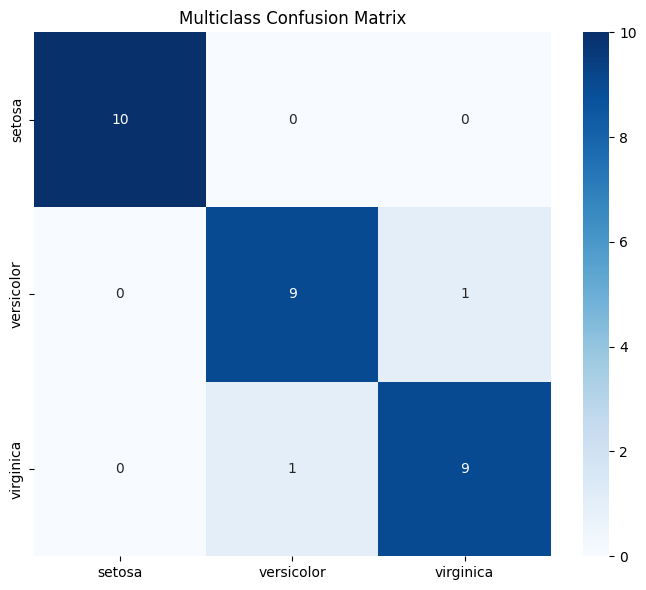

In [14]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

data = load_iris()
X, y = data.data, data.target
class_names = data.target_names
# y = 0 (setosa), 1 (versicolor), 2 (virginica)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    objective     = "multi:softprob",   # returns probabilities per class
    num_class     = 3,                  # must specify number of classes
    n_estimators  = 200,
    max_depth     = 4,
    learning_rate = 0.1,
    random_state  = 42,
)
model.fit(X_train, y_train)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)
# y_pred_prob shape: (n_samples, 3)
# y_pred_prob[0] = [0.02, 0.15, 0.83] → class 2 most likely

print(classification_report(y_test, y_pred, target_names=class_names))

# for each sample show class probabilities
print("\nSample predictions (first 5):")
for i in range(5):
    probs = y_pred_prob[i]
    pred  = y_pred[i]
    true  = y_test[i]
    print(f"  True: {class_names[true]:12} | Pred: {class_names[pred]:12} | "
          f"Probs: {probs.round(3)}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

## SHAP values (explainability)
SHAP explains why the model made each prediction. In finance, regulators require you to explain loan rejections — SHAP is the standard tool for this.

SHAP values shape (class 1): (114, 30)


/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/727465281.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_test, plot_type="bar",


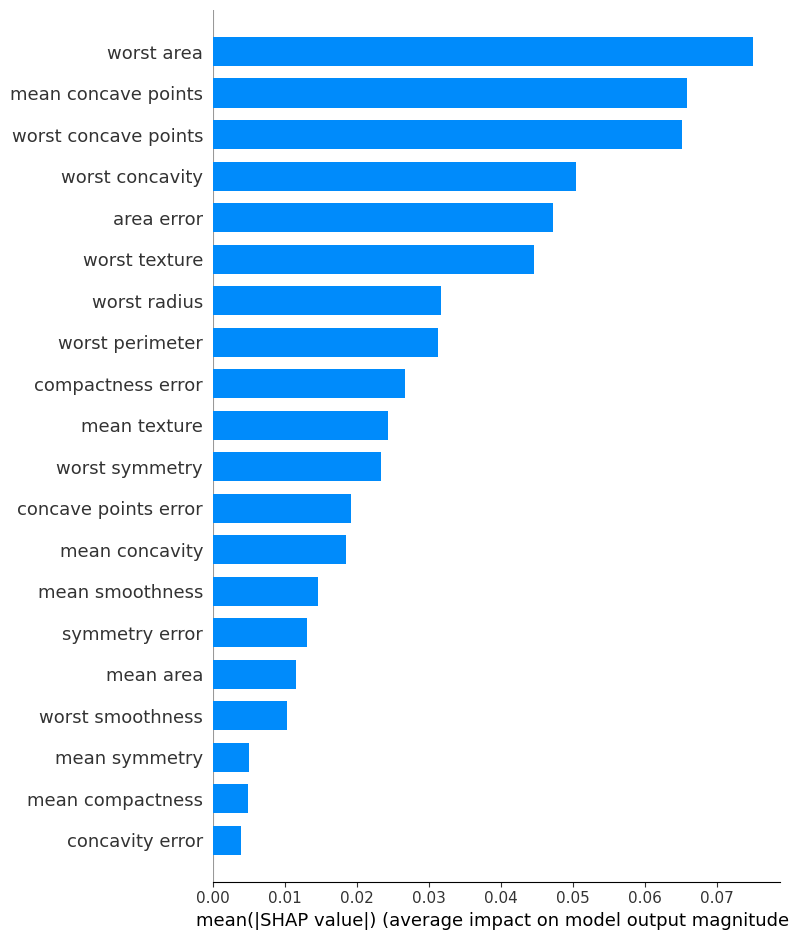

/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/727465281.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_test,


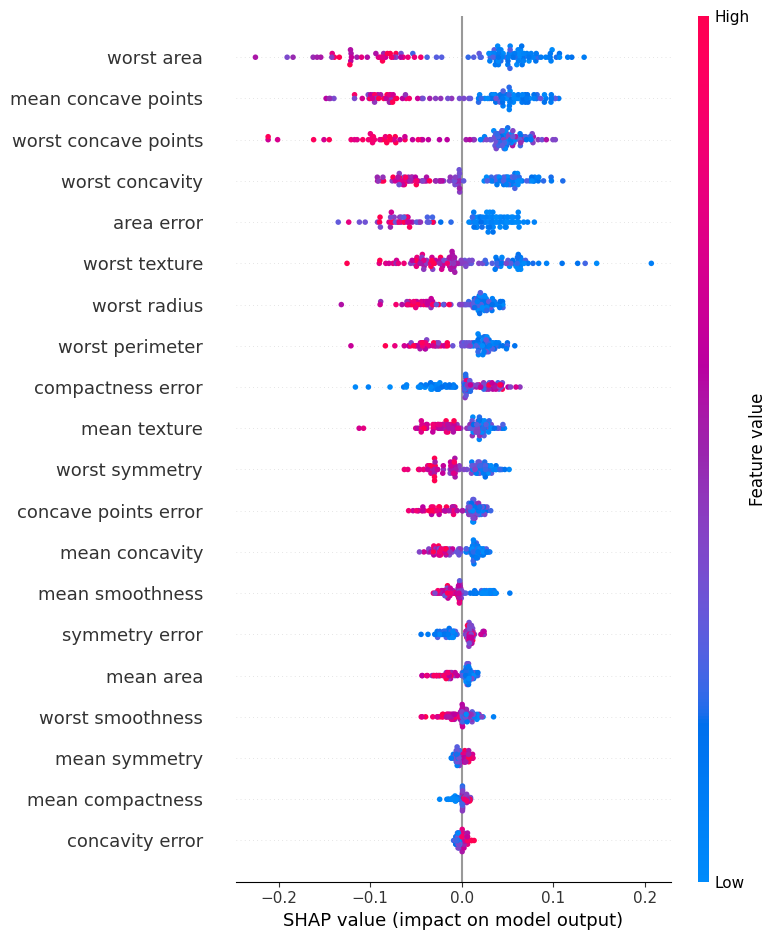


Explaining sample 0:
  Predicted class : 1
  Predicted prob  : 0.9966


AttributeError: 'PermutationExplainer' object has no attribute 'expected_value'

In [26]:
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

X_df = pd.DataFrame(X, columns=feature_names)
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# ── Pass predict_proba as callable — works with any SHAP/XGBoost version ──
# SHAP treats it as a black-box function — no version compatibility issues
# X_train = background dataset SHAP uses as baseline reference
explainer   = shap.Explainer(model.predict_proba, X_train)
shap_values = explainer(X_test)

# shap_values.values shape: (n_samples, n_features, n_classes)
# index [:, :, 1] = SHAP values for class 1 (positive class)
shap_vals_class1 = shap_values.values[:, :, 1]
print(f"SHAP values shape (class 1): {shap_vals_class1.shape}")

# ── Plot 1 — global importance bar ───────────────────────────
shap.summary_plot(shap_vals_class1, X_test, plot_type="bar",
                  feature_names=feature_names, show=True)

# ── Plot 2 — beeswarm ────────────────────────────────────────
shap.summary_plot(shap_vals_class1, X_test,
                  feature_names=feature_names, show=True)

# ── Plot 3 — single prediction waterfall ─────────────────────
sample_idx = 0
print(f"\nExplaining sample {sample_idx}:")
print(f"  Predicted class : {model.predict(X_test.iloc[[sample_idx]])[0]}")
print(f"  Predicted prob  : {model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]:.4f}")

# extract class 1 explanation for the sample
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals_class1[sample_idx],
        base_values   = explainer.expected_value[1],  # baseline for class 1
        data          = X_test.iloc[sample_idx].values,
        feature_names = feature_names,
    )
)

# ── Mean absolute SHAP importance ────────────────────────────
shap_df = pd.DataFrame(shap_vals_class1, columns=feature_names)
print("\nMean |SHAP| per feature (top 10):")
print(shap_df.abs().mean().sort_values(ascending=False).head(10))

SHAP values shape: (114, 30)


/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/2045638809.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_test,


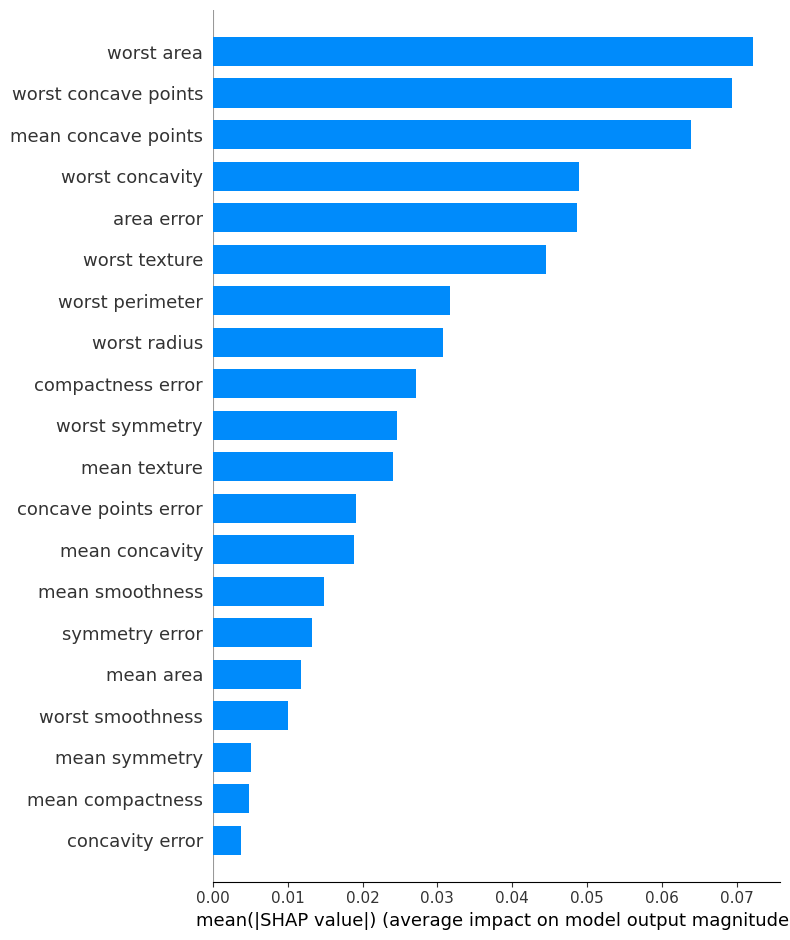

/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/2045638809.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_test,


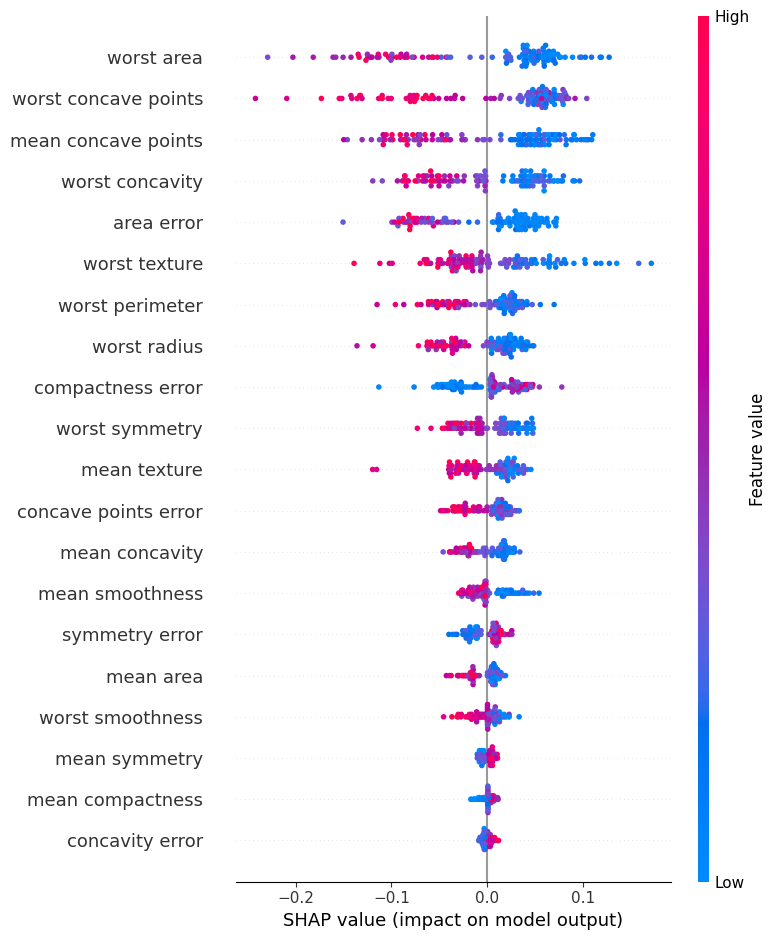


Explaining sample 0:
  Predicted class : 1
  Predicted prob  : 0.9966


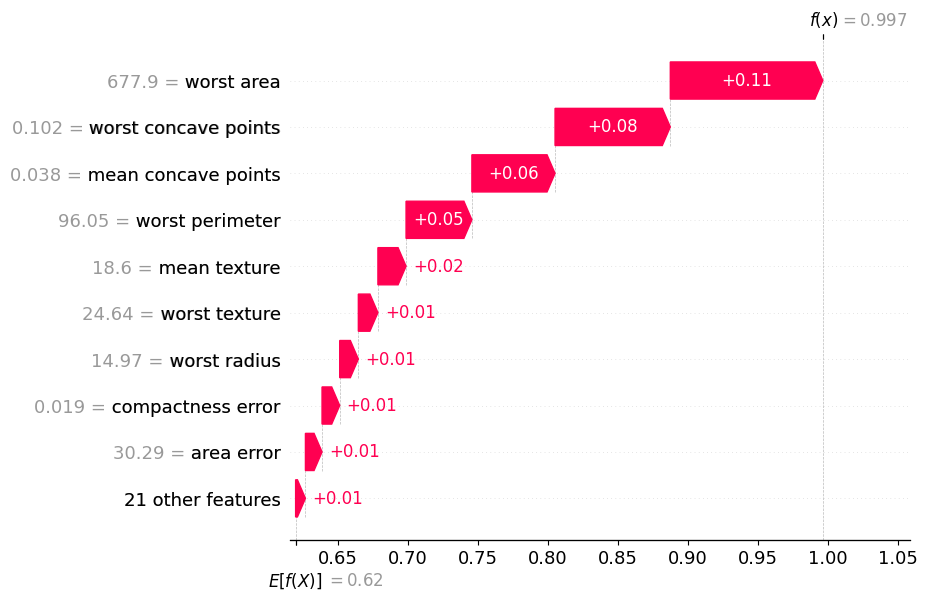


Mean |SHAP| per feature (top 10):
worst area              0.072136
worst concave points    0.069283
mean concave points     0.063887
worst concavity         0.048881
area error              0.048696
worst texture           0.044452
worst perimeter         0.031636
worst radius            0.030738
compactness error       0.027096
worst symmetry          0.024644
dtype: float64


In [27]:
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

X_df = pd.DataFrame(X, columns=feature_names)
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)

explainer   = shap.Explainer(model.predict_proba, X_train)
shap_values = explainer(X_test)

# shap_values.values shape: (n_samples, n_features, n_classes)
# [:, :, 1] = SHAP values for class 1 (positive/malignant)
shap_vals_class1 = shap_values.values[:, :, 1]
print(f"SHAP values shape: {shap_vals_class1.shape}")

# ── Plot 1 — global importance bar ───────────────────────────
shap.summary_plot(shap_vals_class1, X_test,
                  plot_type="bar", feature_names=feature_names, show=True)

# ── Plot 2 — beeswarm ────────────────────────────────────────
shap.summary_plot(shap_vals_class1, X_test,
                  feature_names=feature_names, show=True)

# ── Plot 3 — single prediction waterfall ─────────────────────
sample_idx = 0
print(f"\nExplaining sample {sample_idx}:")
print(f"  Predicted class : {model.predict(X_test.iloc[[sample_idx]])[0]}")
print(f"  Predicted prob  : {model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]:.4f}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals_class1[sample_idx],
        base_values   = shap_values.base_values[sample_idx, 1],  # ← fix here
        data          = X_test.iloc[sample_idx].values,
        feature_names = feature_names,
    )
)

# ── Mean absolute SHAP importance ────────────────────────────
shap_df = pd.DataFrame(shap_vals_class1, columns=feature_names)
print("\nMean |SHAP| per feature (top 10):")
print(shap_df.abs().mean().sort_values(ascending=False).head(10))

## Model saving and loading

In [18]:
import xgboost as xgb
import joblib
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# ── Format 1 — .ubj (native XGBoost binary) ──────────────────
# best: smallest file, fastest to load, preserves all metadata
model.save_model("model.ubj")
m1 = xgb.XGBClassifier()
m1.load_model("model.ubj")
print(f"ubj  | size: {os.path.getsize('model.ubj')//1024} KB "
      f"| acc: {accuracy_score(y_test, m1.predict(X_test)):.4f}")

# ── Format 2 — .json (human readable) ────────────────────────
# good for: debugging, version control, inspecting tree structure
model.save_model("model.json")
m2 = xgb.XGBClassifier()
m2.load_model("model.json")
print(f"json | size: {os.path.getsize('model.json')//1024} KB "
      f"| acc: {accuracy_score(y_test, m2.predict(X_test)):.4f}")

# ── Format 3 — .pkl via joblib ────────────────────────────────
# best for sklearn Pipelines (saves preprocessing steps too)
joblib.dump(model, "model.pkl")
m3 = joblib.load("model.pkl")
print(f"pkl  | size: {os.path.getsize('model.pkl')//1024} KB "
      f"| acc: {accuracy_score(y_test, m3.predict(X_test)):.4f}")

# ── Which format to use ───────────────────────────────────────
# standalone XGBoost model → .ubj (fastest, smallest)
# need to inspect the model → .json (readable)
# sklearn Pipeline → .pkl  (preserves all preprocessing steps)

ubj  | size: 156 KB | acc: 0.9561
json | size: 119 KB | acc: 0.9561
pkl  | size: 159 KB | acc: 0.9561


## Financial use case: Credit default prediction
This is directly applicable to the Natixis Fins'AIght project — predicting whether a client will default on a loan.

In [19]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
n = 15000

# synthetic credit dataset — realistic feature set
df = pd.DataFrame({
    "age":               np.random.randint(18, 75, n),
    "income":            np.random.lognormal(10.5, 0.8, n),
    "debt_to_income":    np.random.beta(2, 5, n),
    "credit_score":      np.random.randint(300, 850, n),
    "loan_amount":       np.random.lognormal(10, 1, n),
    "loan_term_months":  np.random.choice([12, 24, 36, 48, 60], n),
    "employment_years":  np.random.exponential(5, n).clip(0, 40),
    "num_late_payments": np.random.poisson(0.5, n),
    "num_credit_lines":  np.random.randint(1, 20, n),
    "loan_purpose":      np.random.choice(["home", "car", "education", "personal"], n),
})

# default probability — realistic formula (lower credit score = higher default risk)
default_prob = (
    0.3
    - 0.0003 * df["credit_score"]
    + 0.4    * df["debt_to_income"]
    + 0.02   * df["num_late_payments"]
    - 0.005  * df["employment_years"]
).clip(0.02, 0.95)

df["default"] = (np.random.rand(n) < default_prob).astype(int)
print(f"Default rate: {df['default'].mean():.1%}")

# feature engineering — create meaningful derived features
le = LabelEncoder()
df["loan_purpose_enc"]   = le.fit_transform(df["loan_purpose"])
df["loan_to_income"]     = df["loan_amount"] / df["income"]
df["monthly_payment"]    = df["loan_amount"] / df["loan_term_months"]
df["payment_to_income"]  = df["monthly_payment"] / (df["income"] / 12)

features = [
    "age", "income", "debt_to_income", "credit_score",
    "loan_amount", "loan_term_months", "employment_years",
    "num_late_payments", "num_credit_lines", "loan_purpose_enc",
    "loan_to_income", "monthly_payment", "payment_to_income",
]

X = df[features].values
y = df["default"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# handle imbalance with scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = neg / pos,
    eval_metric           = "auc",
    early_stopping_rounds = 30,
    random_state          = 42,
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)], verbose=100)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# risk segmentation — assign risk label to each client
df_test = pd.DataFrame(X_test, columns=features)
df_test["default_prob"] = y_pred_prob
df_test["risk_segment"] = pd.cut(
    df_test["default_prob"],
    bins=[0, 0.1, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High", "Very High"],
)
print("\nRisk distribution:")
print(df_test["risk_segment"].value_counts().sort_index())

# SHAP for regulatory compliance — explain each prediction
# in finance, regulators require you to explain WHY a loan was refused
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:200])

shap.summary_plot(shap_values, X_test[:200], feature_names=features,
                  plot_type="bar", show=True)

Default rate: 23.2%
[0]	validation_0-auc:0.59919
[61]	validation_0-auc:0.61843
              precision    recall  f1-score   support

  No Default       0.82      0.59      0.69      2304
     Default       0.30      0.58      0.39       696

    accuracy                           0.59      3000
   macro avg       0.56      0.58      0.54      3000
weighted avg       0.70      0.59      0.62      3000

ROC AUC: 0.6225

Risk distribution:
risk_segment
Low             0
Medium        104
High         2603
Very High     293
Name: count, dtype: int64


ValueError: could not convert string to float: '[5E-1]'

Default rate: 23.2%
Train : (12000, 13) | Test : (3000, 13)
Default in train : 23.2% | test : 23.2%
scale_pos_weight : 3.3
[0]	validation_0-auc:0.59919
[61]	validation_0-auc:0.61843

MODEL EVALUATION
              precision    recall  f1-score   support

  No Default       0.82      0.59      0.69      2304
     Default       0.30      0.58      0.39       696

    accuracy                           0.59      3000
   macro avg       0.56      0.58      0.54      3000
weighted avg       0.70      0.59      0.62      3000

ROC AUC: 0.6225

Risk distribution:
risk_segment
Low             0
Medium        104
High         2603
Very High     293
Name: count, dtype: int64

Computing SHAP values (this may take ~1 min)...
SHAP values shape: (200, 13)

Plot 1: Global Feature Importance


/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/3064794184.py:129: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


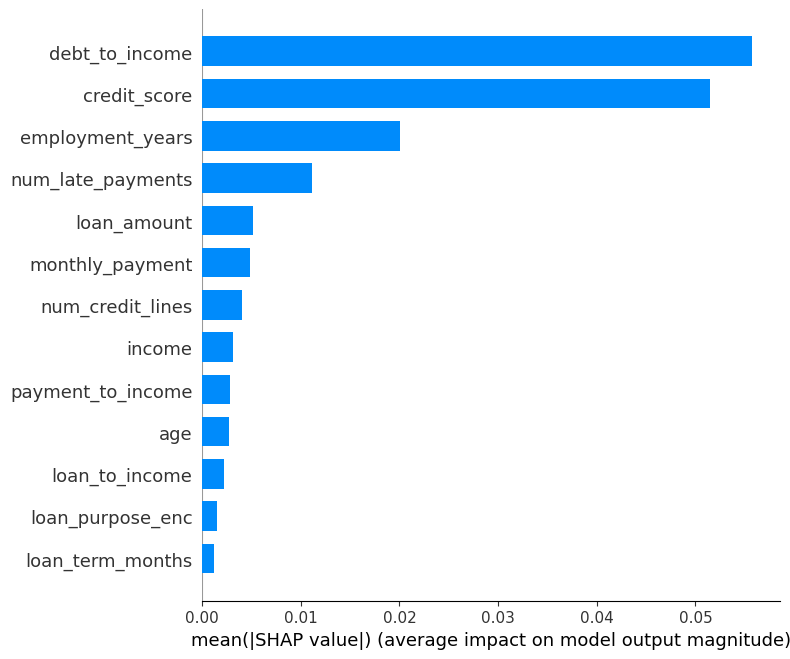


Plot 2: Beeswarm (direction + magnitude)


/var/folders/h2/hlt0n3hj3jx4phv5m7ncq2180000gn/T/ipykernel_9750/3064794184.py:140: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


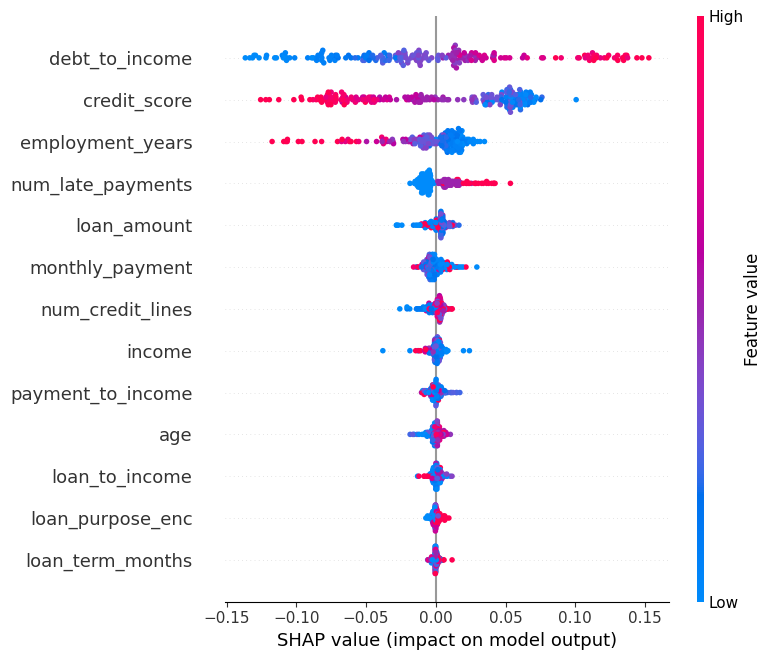


Loan explanation for sample 0:
  Decision            : APPROVED
  Default probability : 0.4753


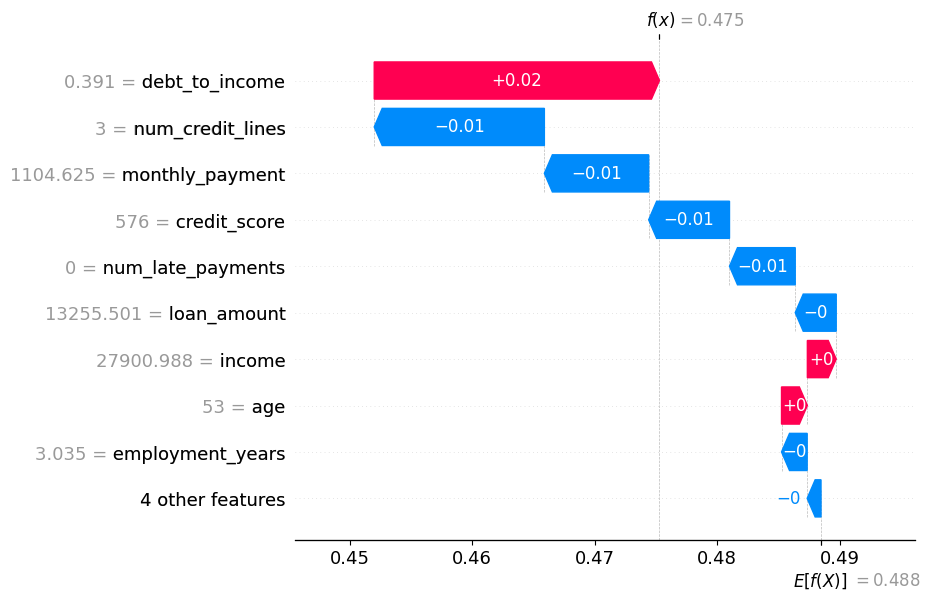


Top features driving default risk (mean |SHAP|):
debt_to_income       0.055789
credit_score         0.051501
employment_years     0.020033
num_late_payments    0.011083
loan_amount          0.005102
monthly_payment      0.004808
num_credit_lines     0.003994
income               0.003117
payment_to_income    0.002853
age                  0.002709
dtype: float64


In [28]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
n = 15000

# ── Synthetic credit dataset ──────────────────────────────────
df = pd.DataFrame({
    "age":               np.random.randint(18, 75, n),
    "income":            np.random.lognormal(10.5, 0.8, n),
    "debt_to_income":    np.random.beta(2, 5, n),
    "credit_score":      np.random.randint(300, 850, n),
    "loan_amount":       np.random.lognormal(10, 1, n),
    "loan_term_months":  np.random.choice([12, 24, 36, 48, 60], n),
    "employment_years":  np.random.exponential(5, n).clip(0, 40),
    "num_late_payments": np.random.poisson(0.5, n),
    "num_credit_lines":  np.random.randint(1, 20, n),
    "loan_purpose":      np.random.choice(["home", "car", "education", "personal"], n),
})

# default probability — lower credit score = higher default risk
default_prob = (
    0.3
    - 0.0003 * df["credit_score"]
    + 0.4    * df["debt_to_income"]
    + 0.02   * df["num_late_payments"]
    - 0.005  * df["employment_years"]
).clip(0.02, 0.95)

df["default"] = (np.random.rand(n) < default_prob).astype(int)
print(f"Default rate: {df['default'].mean():.1%}")

# ── Feature engineering ───────────────────────────────────────
le = LabelEncoder()
df["loan_purpose_enc"]  = le.fit_transform(df["loan_purpose"])
df["loan_to_income"]    = df["loan_amount"] / df["income"]
df["monthly_payment"]   = df["loan_amount"] / df["loan_term_months"]
df["payment_to_income"] = df["monthly_payment"] / (df["income"] / 12)

features = [
    "age", "income", "debt_to_income", "credit_score",
    "loan_amount", "loan_term_months", "employment_years",
    "num_late_payments", "num_credit_lines", "loan_purpose_enc",
    "loan_to_income", "monthly_payment", "payment_to_income",
]

# ── Fix 1 — keep as DataFrame (preserves feature names for XGBoost) ──
X = df[features]       # DataFrame not .values — improves model performance
y = df["default"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Default in train : {y_train.mean():.1%} | test : {y_test.mean():.1%}")

# ── Handle imbalance ──────────────────────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print(f"scale_pos_weight : {neg/pos:.1f}")

# ── Model ─────────────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = neg / pos,
    eval_metric           = "auc",
    early_stopping_rounds = 30,
    random_state          = 42,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 100,
)

# ── Evaluation ────────────────────────────────────────────────
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# ── Risk segmentation ─────────────────────────────────────────
# assign each client a risk label based on their default probability
df_test = X_test.copy()
df_test["default_prob"] = y_pred_prob
df_test["risk_segment"] = pd.cut(
    df_test["default_prob"],
    bins   = [0, 0.1, 0.3, 0.6, 1.0],
    labels = ["Low", "Medium", "High", "Very High"],
)

print("\nRisk distribution:")
print(df_test["risk_segment"].value_counts().sort_index())

# ── SHAP — Fix 2 — use predict_proba callable ─────────────────
# bypasses the XGBoost 2.0 base_score format incompatibility
# with shap.TreeExplainer — works regardless of version

# use a small background sample for speed (100 rows is enough)
X_train_bg     = X_train.iloc[:100]
X_test_sample  = X_test.iloc[:200]

print("\nComputing SHAP values (this may take ~1 min)...")
explainer   = shap.Explainer(model.predict_proba, X_train_bg)
shap_values = explainer(X_test_sample)

# shap_values.values shape: (200, n_features, 2)
# [:, :, 1] = SHAP contributions for class 1 (Default)
shap_vals = shap_values.values[:, :, 1]
print(f"SHAP values shape: {shap_vals.shape}")

# ── Plot 1 — global feature importance (bar) ─────────────────
print("\nPlot 1: Global Feature Importance")
shap.summary_plot(
    shap_vals, X_test_sample,
    feature_names = features,
    plot_type     = "bar",
    show          = True,
)

# ── Plot 2 — beeswarm (direction + magnitude per feature) ─────
# red   = high feature value pushes towards default
# blue  = low feature value pushes away from default
print("\nPlot 2: Beeswarm (direction + magnitude)")
shap.summary_plot(
    shap_vals, X_test_sample,
    feature_names = features,
    show          = True,
)

# ── Plot 3 — explain one specific loan decision ───────────────
# this is what you show regulators when a loan is refused
sample_idx  = 0
pred_class  = model.predict(X_test_sample.iloc[[sample_idx]])[0]
pred_prob   = model.predict_proba(X_test_sample.iloc[[sample_idx]])[0, 1]
decision    = "REFUSED" if pred_class == 1 else "APPROVED"

print(f"\nLoan explanation for sample {sample_idx}:")
print(f"  Decision            : {decision}")
print(f"  Default probability : {pred_prob:.4f}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals[sample_idx],
        base_values   = shap_values.base_values[sample_idx, 1],
        data          = X_test_sample.iloc[sample_idx].values,
        feature_names = features,
    )
)

# ── Top drivers of default risk ───────────────────────────────
shap_df = pd.DataFrame(shap_vals, columns=features)
print("\nTop features driving default risk (mean |SHAP|):")
print(shap_df.abs().mean().sort_values(ascending=False).head(10))

## Full production pipeline class

In [20]:
# plug this class directly into your FastAPI endpoint
# it handles: training, evaluation, cross-validation, saving, loading, prediction

import xgboost as xgb
import numpy as np
import pandas as pd
import joblib
import json
import os
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.datasets import load_breast_cancer


class XGBoostPipeline:
    """
    Production-ready XGBoost pipeline.
    Preprocessing + training + evaluation + saving + loading + prediction.
    """

    def __init__(self, name: str = "xgboost_model"):
        self.name       = name
        self.pipeline   = None
        self.metadata   = {}
        self.is_trained = False

    def build(self, params: dict = None):
        """Build sklearn pipeline: imputer → scaler → XGBoost."""
        if params is None:
            params = {
                "n_estimators":     300,
                "max_depth":        4,
                "learning_rate":    0.05,
                "subsample":        0.8,
                "colsample_bytree": 0.8,
                "reg_alpha":        0.1,
                "reg_lambda":       1.0,
                "random_state":     42,
                "n_jobs":           -1,
            }
        self.pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("xgb",     xgb.XGBClassifier(**params)),
        ])
        return self

    def train(self, X_train, y_train, feature_names=None):
        """Train the pipeline and record metadata."""
        if self.pipeline is None:
            self.build()
        self.pipeline.fit(X_train, y_train)
        self.is_trained     = True
        self.feature_names  = feature_names or [f"f{i}" for i in range(X_train.shape[1])]
        self.metadata.update({
            "name":            self.name,
            "trained_at":      datetime.now().isoformat(),
            "n_features":      X_train.shape[1],
            "n_train_samples": X_train.shape[0],
            "feature_names":   self.feature_names,
        })
        print(f"Trained on {X_train.shape[0]:,} samples | {X_train.shape[1]} features")
        return self

    def evaluate(self, X_test, y_test) -> dict:
        """Evaluate and print all metrics."""
        y_pred      = self.pipeline.predict(X_test)
        y_pred_prob = self.pipeline.predict_proba(X_test)[:, 1]
        metrics = {
            "accuracy": round(accuracy_score(y_test, y_pred), 4),
            "roc_auc":  round(roc_auc_score(y_test, y_pred_prob), 4),
            "f1":       round(f1_score(y_test, y_pred), 4),
        }
        self.metadata["test_metrics"] = metrics
        print("\n" + classification_report(y_test, y_pred))
        for k, v in metrics.items():
            print(f"{k:12}: {v}")
        return metrics

    def cross_validate(self, X, y, cv=5):
        """Stratified K-fold cross validation."""
        skf    = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
        scores = cross_val_score(self.pipeline, X, y, cv=skf,
                                 scoring="roc_auc", n_jobs=-1)
        print(f"{cv}-Fold CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")
        self.metadata["cv"] = {"mean": round(scores.mean(), 4), "std": round(scores.std(), 4)}
        return scores

    def predict(self, X):
        """Predict class labels."""
        return self.pipeline.predict(X)

    def predict_proba(self, X):
        """Predict class probabilities."""
        return self.pipeline.predict_proba(X)

    def save(self, path="."):
        """Save pipeline + metadata."""
        os.makedirs(path, exist_ok=True)
        joblib.dump(self.pipeline, f"{path}/{self.name}.pkl")
        with open(f"{path}/{self.name}_meta.json", "w") as f:
            json.dump(self.metadata, f, indent=2)
        print(f"Saved to {path}/{self.name}.pkl")

    def load(self, path="."):
        """Load pipeline + metadata."""
        self.pipeline = joblib.load(f"{path}/{self.name}.pkl")
        with open(f"{path}/{self.name}_meta.json") as f:
            self.metadata = json.load(f)
        self.is_trained    = True
        self.feature_names = self.metadata.get("feature_names", [])
        print(f"Loaded | trained at: {self.metadata.get('trained_at')}")
        return self


# ── Usage ─────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = XGBoostPipeline("breast_cancer")
pipe.train(X_train, y_train, feature_names=list(data.feature_names))
pipe.cross_validate(X, y, cv=5)
pipe.evaluate(X_test, y_test)
pipe.save("models/")

# reload and predict (simulates FastAPI loading at startup)
pipe2 = XGBoostPipeline("breast_cancer")
pipe2.load("models/")

preds = pipe2.predict(X_test[:5])
probs = pipe2.predict_proba(X_test[:5])[:, 1]

print("\nSample predictions:")
for i, (pred, prob) in enumerate(zip(preds, probs)):
    print(f"  Sample {i}: class={pred}  prob={prob:.4f}")

Trained on 455 samples | 30 features
5-Fold CV AUC: 0.9944 ± 0.0044

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

accuracy    : 0.9474
roc_auc     : 0.9947
f1          : 0.9589
Saved to models//breast_cancer.pkl
Loaded | trained at: 2026-05-02T22:27:48.992521

Sample predictions:
  Sample 0: class=0  prob=0.0007
  Sample 1: class=1  prob=0.9991
  Sample 2: class=0  prob=0.0027
  Sample 3: class=0  prob=0.2256
  Sample 4: class=0  prob=0.0009


## Cheat sheet

In [21]:
# ── Install ───────────────────────────────────────────────────
# pip install xgboost scikit-learn shap optuna imbalanced-learn

# ── Classification ────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,    # imbalanced data
    early_stopping_rounds=30,
    eval_metric="auc", random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# ── Regression ────────────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
)
model.fit(X_train, y_train)

# ── Cross validation ──────────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring="roc_auc")
print(f"{scores.mean():.4f} ± {scores.std():.4f}")

# ── SHAP ──────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# ── Save / load ───────────────────────────────────────────────
model.save_model("model.ubj")       # best for standalone model
joblib.dump(model, "model.pkl")     # best for pipeline

# ── Key parameters ────────────────────────────────────────────
# n_estimators      → number of trees (use early stopping to tune)
# max_depth         → 3–10 (start at 4–6)
# learning_rate     → 0.01–0.3 (lower = more trees needed)
# subsample         → 0.5–1.0 (row sampling)
# colsample_bytree  → 0.5–1.0 (column sampling)
# scale_pos_weight  → neg/pos for imbalanced data
# reg_alpha         → L1 regularization
# reg_lambda        → L2 regularization
# min_child_weight  → conservative splits
# gamma             → min loss reduction for split

# ── Objective functions ───────────────────────────────────────
# binary:logistic   → binary classification
# multi:softprob    → multiclass
# reg:squarederror  → regression MSE
# reg:absoluteerror → regression MAE

# ── Metrics ───────────────────────────────────────────────────
# logloss / auc     → classification
# rmse / mae        → regression

[0]	validation_0-auc:0.99718
[50]	validation_0-auc:1.00000
[60]	validation_0-auc:1.00000


/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 399, in _score
    response_method = _check_response_method(estimator, self._response_method)
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/utils/validation.py", line 2286, in _check_response_method
    raise AttributeError(
AttributeError: XGBRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring 

nan ± nan


/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 399, in _score
    response_method = _check_response_method(estimator, self._response_method)
  File "/opt/anaconda3/envs/venvgenai/lib/python3.10/site-packages/sklearn/utils/validation.py", line 2286, in _check_response_method
    raise AttributeError(
AttributeError: XGBRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


ValueError: could not convert string to float: '[6.2637365E-1]'

In [29]:
import xgboost as xgb
import shap
import joblib
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ── Classification ────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    early_stopping_rounds=30,
    eval_metric="auc", random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# ── Regression ────────────────────────────────────────────────
model_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
)
model_reg.fit(X_train, y_train)

# ── Cross validation ──────────────────────────────────────────
scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring="roc_auc")
print(f"{scores.mean():.4f} ± {scores.std():.4f}")

# ── SHAP — fixed for XGBoost 2.0+ ────────────────────────────
# shap.TreeExplainer breaks on XGBoost 2.0+ due to base_score format change
# fix: pass predict_proba as callable — works on all versions

# for classification
explainer        = shap.Explainer(model.predict_proba, X_train[:100])
shap_values      = explainer(X_test[:200])
shap_vals_class1 = shap_values.values[:, :, 1]   # class 1 SHAP values

shap.summary_plot(shap_vals_class1, X_test[:200], show=True)

# single prediction waterfall
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals_class1[0],
        base_values   = shap_values.base_values[0, 1],
        data          = X_test[:200].iloc[0].values
                        if hasattr(X_test[:200], "iloc")
                        else X_test[0],
        feature_names = list(X_train.columns)
                        if hasattr(X_train, "columns")
                        else [f"f{i}" for i in range(X_train.shape[1])],
    )
)

# for regression — predict directly (no class index needed)
explainer_reg   = shap.Explainer(model_reg.predict, X_train[:100])
shap_values_reg = explainer_reg(X_test[:200])
shap_vals_reg   = shap_values_reg.values          # shape: (200, n_features)

shap.summary_plot(shap_vals_reg, X_test[:200], show=True)

# ── Save / load ───────────────────────────────────────────────
model.save_model("model.ubj")       # best for standalone model
joblib.dump(model, "model.pkl")     # best for pipeline

model2 = xgb.XGBClassifier()
model2.load_model("model.ubj")

# ── Key parameters ────────────────────────────────────────────
# n_estimators      → number of trees (use early stopping to tune)
# max_depth         → 3–10 (start at 4–6)
# learning_rate     → 0.01–0.3 (lower = more trees needed)
# subsample         → 0.5–1.0 (row sampling)
# colsample_bytree  → 0.5–1.0 (column sampling)
# scale_pos_weight  → neg/pos for imbalanced data
# reg_alpha         → L1 regularization
# reg_lambda        → L2 regularization
# min_child_weight  → conservative splits
# gamma             → min loss reduction for split

# ── Objective functions ───────────────────────────────────────
# binary:logistic   → binary classification
# multi:softprob    → multiclass
# reg:squarederror  → regression MSE
# reg:absoluteerror → regression MAE

# ── Metrics ───────────────────────────────────────────────────
# logloss / auc     → classification
# rmse / mae        → regression

# ── SHAP quick reference (XGBoost 2.0+ compatible) ───────────
# classification  → shap.Explainer(model.predict_proba, X_bg)  → values[:, :, 1]
# regression      → shap.Explainer(model.predict, X_bg)        → values directly
# base_values     → shap_values.base_values[i, class_idx]      (not explainer.expected_value)
# never use       → shap.TreeExplainer(model) with XGBoost 2.0+

XGBoostError: [22:39:13] /Users/runner/work/xgboost/xgboost/src/data/quantile_dmatrix.cc:58: Check failed: ref->Info().num_col_ == n_features (13 vs. 30) : Invalid ref DMatrix, different number of features.
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000126803dd8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x0000000126a2ff00 xgboost::data::GetCutsFromRef(xgboost::Context const*, std::__1::shared_ptr<xgboost::DMatrix>, unsigned int, xgboost::BatchParam, xgboost::common::HistogramCuts*) + 388
  [bt] (2) 3   libxgboost.dylib                    0x0000000126a3598c xgboost::data::cpu_impl::MakeSketches(xgboost::Context const*, xgboost::data::DataIterProxy<void (void*), int (void*)>*, xgboost::data::DMatrixProxy*, std::__1::shared_ptr<xgboost::DMatrix>, float, xgboost::common::HistogramCuts*, xgboost::BatchParam const&, xgboost::MetaInfo const&, xgboost::data::ExternalDataInfo const&, std::__1::vector<xgboost::Fe